# Raihan Daris Ramadhan


## Import Library


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Citra Tulisan

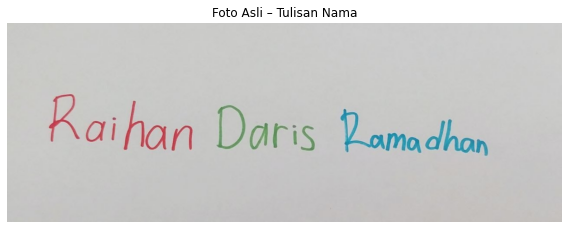

In [2]:
img = cv2.imread("6068673310922313520.jpg")          
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
 
plt.figure(figsize=(8, 4))
plt.imshow(img_rgb)
plt.title("Foto Asli – Tulisan Nama")
plt.axis("off")
plt.tight_layout()
plt.show()

## Konversi BGR ke HSV

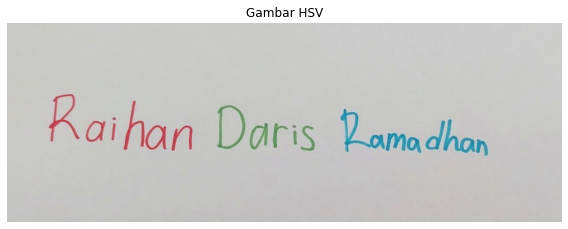

✓ Gambar berhasil dikonversi ke HSV


In [3]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
 
plt.figure(figsize=(8, 4))
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("Gambar HSV")
plt.axis("off")
plt.tight_layout()
plt.show()
 
print("✓ Gambar berhasil dikonversi ke HSV")

## Deteksi Warna Merah

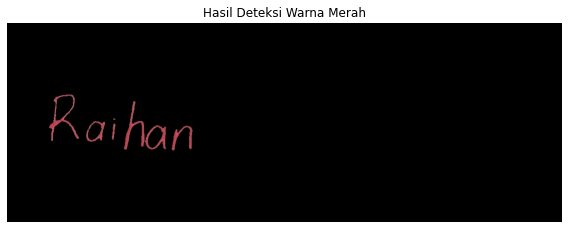

In [4]:
merah_bawah1 = np.array([0,   100, 100])
merah_atas1  = np.array([10,  255, 255])
merah_bawah2 = np.array([160, 100, 100])
merah_atas2  = np.array([179, 255, 255])
 
mask1      = cv2.inRange(hsv, merah_bawah1, merah_atas1)
mask2      = cv2.inRange(hsv, merah_bawah2, merah_atas2)
mask_merah = mask1 + mask2
 
hasil_merah = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_merah)
 
plt.figure(figsize=(8, 4))
plt.imshow(hasil_merah)
plt.title("Hasil Deteksi Warna Merah")
plt.axis("off")
plt.tight_layout()
plt.show()

## Deteksi Warna Hijau

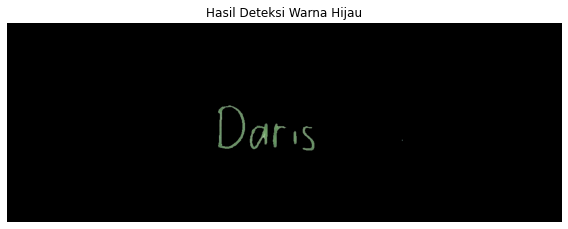

In [5]:
hijau_bawah = np.array([40,  50, 50])
hijau_atas  = np.array([90, 255, 255])
 
mask_hijau  = cv2.inRange(hsv, hijau_bawah, hijau_atas)
hasil_hijau = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_hijau)
 
plt.figure(figsize=(8, 4))
plt.imshow(hasil_hijau)
plt.title("Hasil Deteksi Warna Hijau")
plt.axis("off")
plt.tight_layout()
plt.show()

## Deteksi Warna Biru

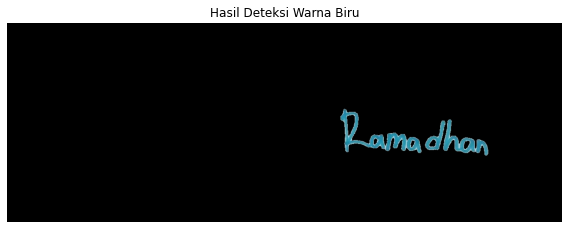

In [9]:
biru_bawah = np.array([90,  50, 50])
biru_atas  = np.array([140, 255, 255])
 
mask_biru  = cv2.inRange(hsv, biru_bawah, biru_atas)
hasil_biru = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_biru)
 
plt.figure(figsize=(8, 4))
plt.imshow(hasil_biru)
plt.title("Hasil Deteksi Warna Biru")
plt.axis("off")
plt.tight_layout()
plt.show()

## Tampilkan Semua 

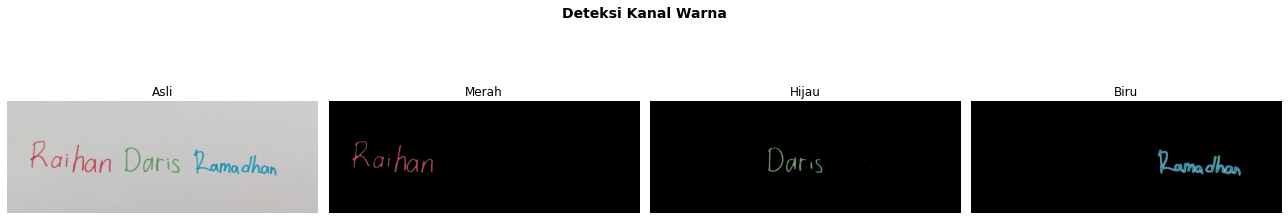

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_rgb);      axes[0].set_title("Asli");  axes[0].axis("off")
axes[1].imshow(hasil_merah);  axes[1].set_title("Merah"); axes[1].axis("off")
axes[2].imshow(hasil_hijau);  axes[2].set_title("Hijau"); axes[2].axis("off")
axes[3].imshow(hasil_biru);   axes[3].set_title("Biru");  axes[3].axis("off")
plt.suptitle("Deteksi Kanal Warna", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Histogram RGB

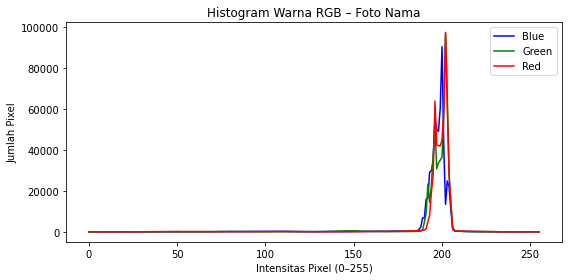

In [11]:
plt.figure(figsize=(8, 4))
label_warna = ["Blue", "Green", "Red"]
for i, (c, label) in enumerate(zip(["b", "g", "r"], label_warna)):
    grafik = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(grafik, color=c, label=label)
 
plt.title("Histogram Warna RGB – Foto Nama")
plt.xlabel("Intensitas Pixel (0–255)")
plt.ylabel("Jumlah Pixel")
plt.legend()
plt.tight_layout()
plt.show()

## Nilai Threshold HSV


=== NILAI THRESHOLD HSV ===
  Merah  : Hue   0–10  DAN 160–179 | Sat 100–255 | Val 100–255
  Hijau  : Hue  40–90              | Sat  50–255 | Val  50–255
  Biru   : Hue 90–140             | Sat  50–255 | Val  50–255


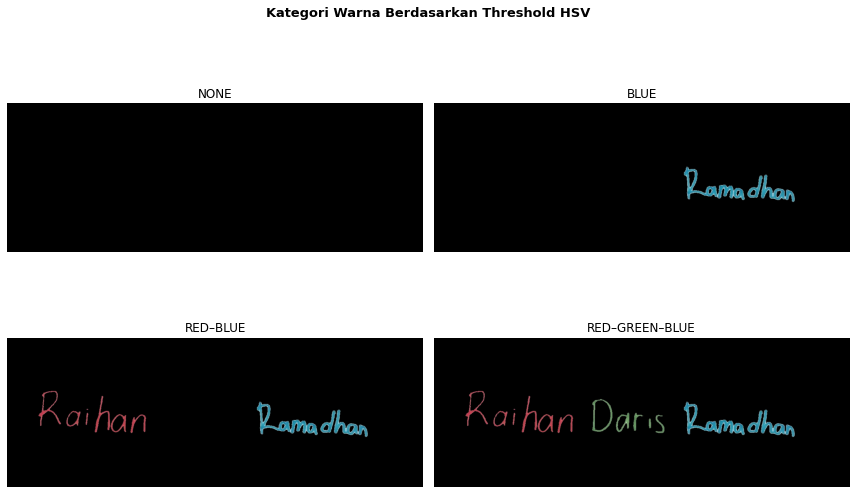

In [12]:
print("\n=== NILAI THRESHOLD HSV ===")
print(f"  Merah  : Hue   0–10  DAN 160–179 | Sat 100–255 | Val 100–255")
print(f"  Hijau  : Hue  40–90              | Sat  50–255 | Val  50–255")
print(f"  Biru   : Hue 90–140             | Sat  50–255 | Val  50–255")
 
# ── 9. Tampil Threshold (NONE / BLUE / RED-BLUE / ALL) ─
mask_none       = np.zeros(img.shape[:2], dtype=np.uint8)
mask_red_blue   = mask_merah + mask_biru
mask_all        = mask_merah + mask_hijau + mask_biru
 
hasil_none      = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_none)
hasil_red_blue  = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_red_blue)
hasil_all       = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_all)
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].imshow(hasil_none);     axes[0,0].set_title("NONE");          axes[0,0].axis("off")
axes[0,1].imshow(hasil_biru);     axes[0,1].set_title("BLUE");          axes[0,1].axis("off")
axes[1,0].imshow(hasil_red_blue); axes[1,0].set_title("RED–BLUE");      axes[1,0].axis("off")
axes[1,1].imshow(hasil_all);      axes[1,1].set_title("RED–GREEN–BLUE");axes[1,1].axis("off")
plt.suptitle("Kategori Warna Berdasarkan Threshold HSV", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Membaca Gambar Backlight

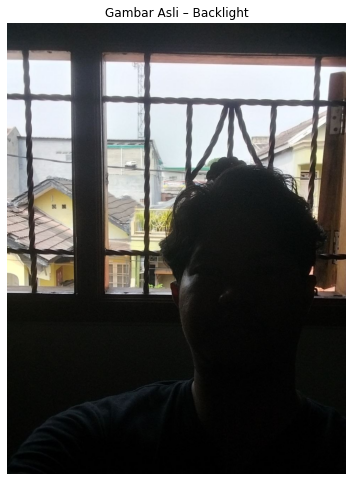

In [13]:
img2     = cv2.imread("6068673310922313512.jpg")   
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
 
plt.figure(figsize=(5, 7))
plt.imshow(img2_rgb)
plt.title("Gambar Asli – Backlight")
plt.axis("off")
plt.tight_layout()
plt.show()

## Konversi Ke Gray

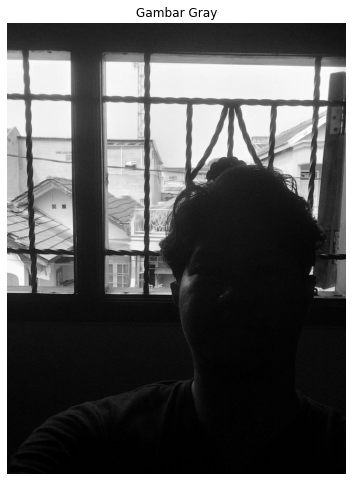

In [14]:
abu = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
 
plt.figure(figsize=(5, 7))
plt.imshow(abu, cmap="gray")
plt.title("Gambar Gray")
plt.axis("off")
plt.tight_layout()
plt.show()

## Hasil Brightness

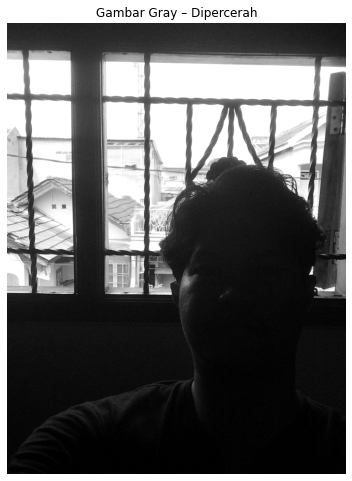

In [17]:
terang = cv2.convertScaleAbs(abu, alpha=1, beta=35)
 
plt.figure(figsize=(5, 7))
plt.imshow(terang, cmap="gray")
plt.title("Gambar Gray – Dipercerah")
plt.axis("off")
plt.tight_layout()
plt.show()

## Peningkatan Kontras

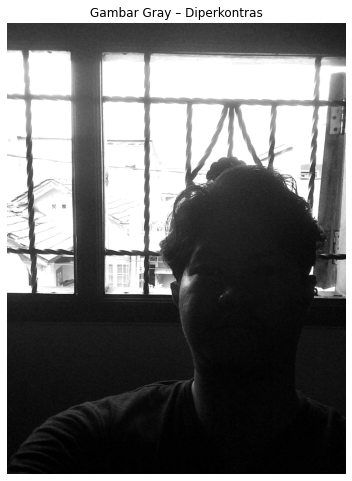

In [18]:
kontras = cv2.convertScaleAbs(abu, alpha=1.7, beta=0)
 
plt.figure(figsize=(5, 7))
plt.imshow(kontras, cmap="gray")
plt.title("Gambar Gray – Diperkontras")
plt.axis("off")
plt.tight_layout()
plt.show()

## Kombinasi Brightness + Contrast

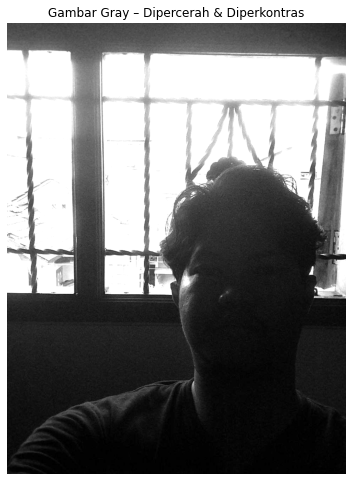

In [19]:
hasil = cv2.convertScaleAbs(abu, alpha=2, beta=30)
 
plt.figure(figsize=(5, 7))
plt.imshow(hasil, cmap="gray")
plt.title("Gambar Gray – Dipercerah & Diperkontras")
plt.axis("off")
plt.tight_layout()
plt.show()